# Scene Text Pipeline: Swin2SR Enhancement → TrOCR Recognition

**Pipeline:**
1. **Load** — Handle 16-bit grayscale TIF images
2. **Enhance** — Swin2SR super-resolution (no basicsr/realesrgan needed)
3. **Detect** — EasyOCR finds bounding boxes for each text region
4. **Recognize** — TrOCR reads each text region
5. **Save** — Output written line-by-line to `dataset/output/<filename>.txt`

## 1. Install Dependencies

In [3]:
!pip install transformers accelerate
!pip install opencv-python-headless Pillow tqdm matplotlib
!pip install easyocr
!pip install sentencepiece

## 2. Imports & Device

In [4]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm
from transformers import (
    Swin2SRImageProcessor, Swin2SRForImageSuperResolution,
    TrOCRProcessor, VisionEncoderDecoderModel
)
import easyocr

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device   : {DEVICE}")

/Users/praneethudayakumar227/Documents/GitHub/SceneTextRecognizer/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch  : 2.11.0
CUDA     : False
Device   : cpu


## 3. Configuration

In [ ]:
INPUT_DIR    = "dataset/raw"
ENHANCED_DIR = "dataset/enhanced"
OUTPUT_DIR   = "dataset/output"

for d in [INPUT_DIR, ENHANCED_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

# Swin2SR: 4x real-world super-resolution (no basicsr needed)
SWIN2SR_MODEL = 'caidas/swin2SR-realworld-sr-x4-64-bsrgan-psnr'
SR_SCALE      = 4

# Tile size: keeps GPU memory under control.
# 256 is safe on a 15 GB GPU.  Lower to 128 if still OOM.  CPU can use 512+.
TILE_SIZE     = 256 if torch.cuda.is_available() else 512

# TrOCR: trocr-base-printed (fast) or trocr-large-printed (accurate)
TROCR_MODEL   = 'microsoft/trocr-base-printed'

DETECT_LANGS  = ['en']

print(f"Config ready.  TILE_SIZE={TILE_SIZE}  SR={SR_SCALE}x  Device={DEVICE}")

## 4. Load Models

In [ ]:
import gc

MODEL_DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32
print(f"Model dtype: {MODEL_DTYPE}")

def free_gpu():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

# ── Swin2SR ───────────────────────────────────────────────────────────────────
free_gpu()
print("Loading Swin2SR...")
sr_processor = Swin2SRImageProcessor()
sr_model     = Swin2SRForImageSuperResolution.from_pretrained(
    SWIN2SR_MODEL, torch_dtype=MODEL_DTYPE
).to(DEVICE)
sr_model.eval()
print(f"  Swin2SR ready  ({MODEL_DTYPE})")

# ── EasyOCR detector ──────────────────────────────────────────────────────────
free_gpu()
print("Loading EasyOCR detector...")
detector = easyocr.Reader(DETECT_LANGS, gpu=torch.cuda.is_available(), recognizer=False)
print("  EasyOCR detector ready.")

# ── TrOCR ─────────────────────────────────────────────────────────────────────
free_gpu()
print(f"Loading TrOCR ({TROCR_MODEL})...")
trocr_processor = TrOCRProcessor.from_pretrained(TROCR_MODEL)
trocr_model     = VisionEncoderDecoderModel.from_pretrained(
    TROCR_MODEL, torch_dtype=MODEL_DTYPE
).to(DEVICE)
trocr_model.eval()
print("  TrOCR ready.")

free_gpu()
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**3
    total     = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"\nGPU memory: {allocated:.1f} GB used / {total:.1f} GB total")
print("All models loaded!")

## 5. Core Functions

In [ ]:
def load_as_uint8_bgr(img_path):
    """Load any image including 16-bit TIF as 8-bit BGR numpy array."""
    pil = Image.open(img_path)
    arr = np.array(pil)

    if arr.dtype == np.uint16:
        arr = (arr / 256).astype(np.uint8)
    elif arr.dtype != np.uint8:
        arr = ((arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255).astype(np.uint8)

    if arr.ndim == 2:
        arr = cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR)
    elif arr.shape[2] == 4:
        arr = cv2.cvtColor(arr, cv2.COLOR_RGBA2BGR)
    elif arr.shape[2] == 3:
        arr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
    return arr


def enhance_image(img_path):
    """Tiled Swin2SR enhancement to avoid OOM."""
    bgr = load_as_uint8_bgr(img_path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    H, W = rgb.shape[:2]

    out_H, out_W = H * SR_SCALE, W * SR_SCALE
    output = np.zeros((out_H, out_W, 3), dtype=np.uint8)

    y = 0
    while y < H:
        x = 0
        while x < W:
            x2 = min(x + TILE_SIZE, W)
            y2 = min(y + TILE_SIZE, H)
            tile = rgb[y:y2, x:x2]

            ph = (8 - tile.shape[0] % 8) % 8
            pw = (8 - tile.shape[1] % 8) % 8
            if ph > 0 or pw > 0:
                tile = np.pad(tile, ((0, ph), (0, pw), (0, 0)), mode='reflect')

            pil_tile = Image.fromarray(tile)
            inputs   = sr_processor(images=pil_tile, return_tensors='pt')
            inputs   = {k: v.to(DEVICE, dtype=MODEL_DTYPE) for k, v in inputs.items()}

            with torch.no_grad():
                out = sr_model(**inputs)

            sr_np = (out.reconstruction.squeeze().float().cpu().clamp(0, 1)
                     .permute(1, 2, 0).numpy() * 255).astype(np.uint8)

            th_out = (y2 - y) * SR_SCALE
            tw_out = (x2 - x) * SR_SCALE
            output[y * SR_SCALE : y2 * SR_SCALE,
                   x * SR_SCALE : x2 * SR_SCALE] = sr_np[:th_out, :tw_out]

            free_gpu()
            x += TILE_SIZE
        y += TILE_SIZE

    return cv2.cvtColor(output, cv2.COLOR_RGB2BGR)


def detect_text_regions(bgr):
    """
    EasyOCR detect() returns ([[box, ...]], [[free, ...]]) — one list per image.
    Each box: [x_min, x_max, y_min, y_max]
    """
    raw, _ = detector.detect(bgr)
    horizontal_list = raw[0]   # unwrap per-image wrapper
    h, w = bgr.shape[:2]
    boxes = []
    for box in horizontal_list:
        x1, x2, y1, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        if x2 > x1 and y2 > y1:
            boxes.append((x1, y1, x2, y2))
    boxes.sort(key=lambda b: (b[1], b[0]))
    return boxes


def recognize_crop(crop_bgr):
    """Run TrOCR on a single cropped region."""
    pil_img      = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)).convert('RGB')
    pixel_values = trocr_processor(images=pil_img, return_tensors='pt').pixel_values
    pixel_values = pixel_values.to(DEVICE, dtype=MODEL_DTYPE)
    with torch.no_grad():
        ids = trocr_model.generate(pixel_values)
    return trocr_processor.batch_decode(ids, skip_special_tokens=True)[0].strip()


def process_image(img_path, save_enhanced=True):
    """Full pipeline: enhance -> detect -> recognize."""
    fname    = os.path.splitext(os.path.basename(img_path))[0]
    enhanced = enhance_image(img_path)

    if save_enhanced:
        cv2.imwrite(os.path.join(ENHANCED_DIR, f"{fname}_enhanced.png"), enhanced)

    boxes = detect_text_regions(enhanced)
    if not boxes:
        return enhanced, [], ['[No text detected]']

    lines = [recognize_crop(enhanced[y1:y2, x1:x2]) for x1, y1, x2, y2 in boxes]
    lines = [l for l in lines if l]
    return enhanced, boxes, lines


def save_text_output(lines, fname):
    out_path = os.path.join(OUTPUT_DIR, f"{fname}.txt")
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines) + '\n')
    return out_path


print("Functions defined.")

## 6. Test on a Single Image

In [8]:
# Auto-picks the first .tif in dataset/raw
tif_files = sorted([
    os.path.join(INPUT_DIR, f) for f in os.listdir(INPUT_DIR)
    if os.path.splitext(f)[1].lower() in ('.tif', '.tiff')
])
TEST_IMAGE = tif_files[0]
print(f"Testing with: {TEST_IMAGE}")

fname               = os.path.splitext(os.path.basename(TEST_IMAGE))[0]
enhanced, boxes, lines = process_image(TEST_IMAGE, save_enhanced=True)

print(f"\nDetected {len(boxes)} region(s):")
for i, text in enumerate(lines):
    print(f"  Line {i+1:02d}: {text}")

out_path = save_text_output(lines, fname)
print(f"\nSaved -> {out_path}")

# Visualize
orig_bgr = load_as_uint8_bgr(TEST_IMAGE)
enh_rgb  = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Original  {orig_bgr.shape[1]}x{orig_bgr.shape[0]}", fontsize=12)
axes[0].axis('off')

axes[1].imshow(enh_rgb)
axes[1].set_title(f"Enhanced + Regions  {enhanced.shape[1]}x{enhanced.shape[0]}", fontsize=12)
axes[1].axis('off')
for i, (x1, y1, x2, y2) in enumerate(boxes):
    axes[1].add_patch(patches.Rectangle(
        (x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='lime', facecolor='none'))
    axes[1].text(x1, max(y1-6, 0), lines[i] if i < len(lines) else '',
                 color='yellow', fontsize=8, weight='bold',
                 bbox=dict(facecolor='black', alpha=0.5, pad=1))

plt.tight_layout()
plt.show()

Testing with: dataset/raw/focusStep_0_timesR_size_30_sample_0001.tif


: 

## 7. Batch Processing

In [ ]:
image_paths = [
    os.path.join(INPUT_DIR, f)
    for f in sorted(os.listdir(INPUT_DIR))
    if os.path.splitext(f)[1].lower() in SUPPORTED_EXTS
]

if not image_paths:
    print(f"No images found in {INPUT_DIR}")
else:
    print(f"Processing {len(image_paths)} image(s)...\n")
    for img_path in tqdm(image_paths):
        fname    = os.path.splitext(os.path.basename(img_path))[0]
        txt_path = os.path.join(OUTPUT_DIR, f"{fname}.txt")

        if os.path.exists(txt_path):
            tqdm.write(f"  [SKIP] {fname}")
            continue
        try:
            _, _, lines = process_image(img_path, save_enhanced=True)
            out_path    = save_text_output(lines, fname)
            tqdm.write(f"  [OK]   {fname} -> {len(lines)} line(s)")
        except Exception as e:
            tqdm.write(f"  [ERR]  {fname}: {e}")

    print(f"\nDone!  Enhanced -> {ENHANCED_DIR}/   Text -> {OUTPUT_DIR}/")

## 8. Image Quality Evaluation — SSIM & PSNR (dataset_results_34)

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

RAW_DIR      = "dataset_results_34/raw"
ENHANCED_DIR = "dataset_results_34/enhanced"

# ── helpers ──────────────────────────────────────────────────────────────────
def load_raw(path):
    """Load 16-bit TIF (or any image) → uint8 RGB numpy array."""
    pil = Image.open(path)
    arr = np.array(pil)
    if arr.dtype == np.uint16:
        arr = (arr / 256).astype(np.uint8)
    elif arr.dtype != np.uint8:
        arr = ((arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255).astype(np.uint8)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    elif arr.shape[2] == 4:
        arr = arr[:, :, :3]
    return arr  # RGB uint8

def load_enhanced(path):
    """Load enhanced PNG → uint8 RGB numpy array."""
    pil = Image.open(path).convert("RGB")
    return np.array(pil)

# ── build matched pairs ───────────────────────────────────────────────────────
pairs = []
for fname in sorted(os.listdir(ENHANCED_DIR)):
    if not fname.endswith("_enhanced.png"):
        continue
    stem     = fname.replace("_enhanced.png", "")
    raw_path = os.path.join(RAW_DIR, stem + ".tif")
    enh_path = os.path.join(ENHANCED_DIR, fname)
    if os.path.exists(raw_path):
        pairs.append((stem, raw_path, enh_path))

print(f"Found {len(pairs)} matched image pairs.")


Found 56 matched image pairs.


In [3]:
# ── compute SSIM & PSNR for every pair ───────────────────────────────────────
# Strategy: upscale raw to match enhanced size (bicubic), then compare.
results = []

for stem, raw_path, enh_path in pairs:
    raw = load_raw(raw_path)          # e.g. H x W x 3
    enh = load_enhanced(enh_path)     # e.g. 4H x 4W x 3

    # Resize raw up to enhanced dimensions for a fair pixel-level comparison
    raw_up = cv2.resize(raw, (enh.shape[1], enh.shape[0]),
                        interpolation=cv2.INTER_CUBIC)

    # Grayscale versions for SSIM (channel_axis approach also works)
    raw_gray = cv2.cvtColor(raw_up, cv2.COLOR_RGB2GRAY)
    enh_gray = cv2.cvtColor(enh,    cv2.COLOR_RGB2GRAY)

    ssim_val = ssim(raw_gray, enh_gray, data_range=255)
    psnr_val = psnr(raw_gray, enh_gray, data_range=255)

    results.append({
        "stem":  stem,
        "ssim":  ssim_val,
        "psnr":  psnr_val,
        "raw":   raw,
        "enh":   enh,
    })

ssim_vals = [r["ssim"] for r in results]
psnr_vals = [r["psnr"] for r in results]

print("=" * 55)
print(f"  Images evaluated : {len(results)}")
print(f"  SSIM  — mean: {np.mean(ssim_vals):.4f}  "
      f"min: {np.min(ssim_vals):.4f}  max: {np.max(ssim_vals):.4f}")
print(f"  PSNR  — mean: {np.mean(psnr_vals):.2f} dB  "
      f"min: {np.min(psnr_vals):.2f}  max: {np.max(psnr_vals):.2f}")
print("=" * 55)

# Per-image table (first 15 rows)
print(f"\n{'#':<4} {'SSIM':>7} {'PSNR (dB)':>10}  Image")
print("-" * 55)
for i, r in enumerate(results[:15]):
    print(f"{i+1:<4} {r['ssim']:>7.4f} {r['psnr']:>10.2f}  {r['stem']}")
if len(results) > 15:
    print(f"  ... and {len(results)-15} more")


  Images evaluated : 56
  SSIM  — mean: 0.7319  min: 0.7165  max: 0.7566
  PSNR  — mean: 31.77 dB  min: 31.09  max: 32.43

#       SSIM  PSNR (dB)  Image
-------------------------------------------------------
1     0.7301      31.16  focusStep_2_verdanaRef_size_30_sample_0017
2     0.7319      31.09  focusStep_2_verdanaRef_size_30_sample_0018
3     0.7332      31.23  focusStep_2_verdanaRef_size_30_sample_0019
4     0.7250      31.09  focusStep_2_verdanaRef_size_30_sample_0020
5     0.7471      32.14  focusStep_3_timesR_size_30_sample_0001
6     0.7238      31.50  focusStep_3_timesR_size_30_sample_0002
7     0.7406      31.90  focusStep_3_timesR_size_30_sample_0003
8     0.7344      31.86  focusStep_3_timesR_size_30_sample_0004
9     0.7322      31.74  focusStep_3_timesR_size_30_sample_0005
10    0.7339      31.90  focusStep_3_timesR_size_30_sample_0006
11    0.7424      31.96  focusStep_3_timesR_size_30_sample_0007
12    0.7366      32.03  focusStep_3_timesR_size_30_sample_0008
13    

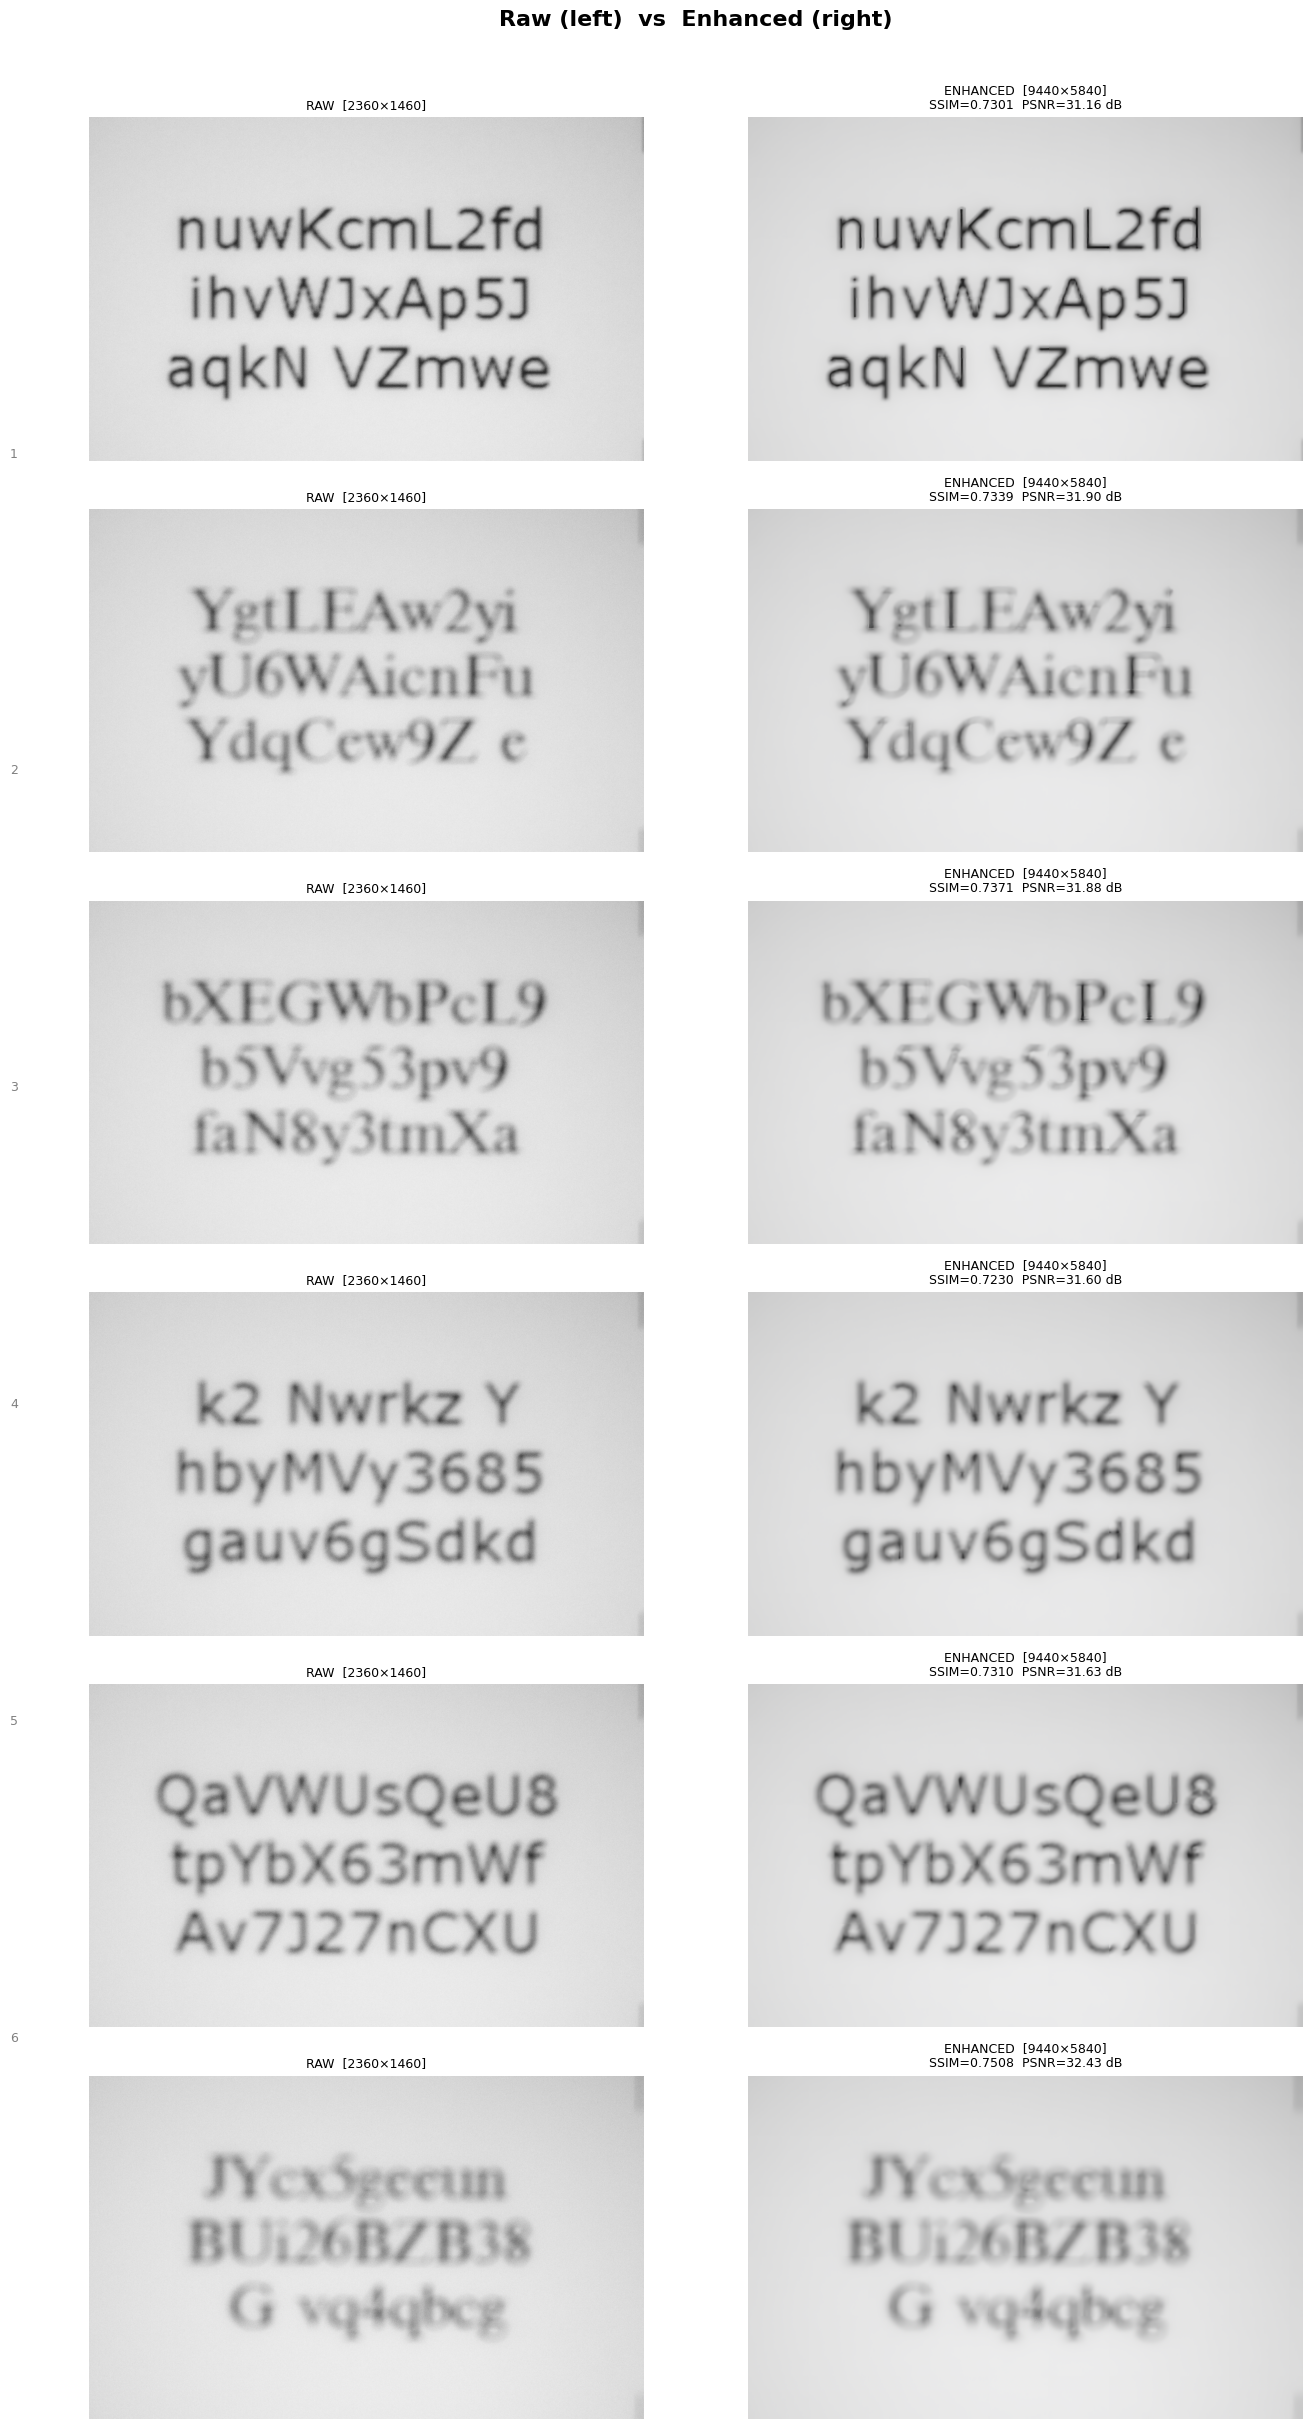

Saved → dataset_results_34/sample_comparison.png


In [4]:
# ── Sample side-by-side gallery (Raw | Enhanced) ─────────────────────────────
N_SAMPLES = 6   # number of sample pairs to display
step      = max(1, len(results) // N_SAMPLES)
samples   = results[::step][:N_SAMPLES]

fig, axes = plt.subplots(N_SAMPLES, 2, figsize=(14, N_SAMPLES * 4))
fig.suptitle("Raw (left)  vs  Enhanced (right)", fontsize=16, fontweight="bold", y=1.01)

for row, r in enumerate(samples):
    ax_raw = axes[row, 0]
    ax_enh = axes[row, 1]

    ax_raw.imshow(r["raw"])
    ax_raw.set_title(f"RAW  [{r['raw'].shape[1]}×{r['raw'].shape[0]}]", fontsize=9)
    ax_raw.axis("off")

    ax_enh.imshow(r["enh"])
    ax_enh.set_title(
        f"ENHANCED  [{r['enh'].shape[1]}×{r['enh'].shape[0]}]\n"
        f"SSIM={r['ssim']:.4f}  PSNR={r['psnr']:.2f} dB",
        fontsize=9,
    )
    ax_enh.axis("off")

    # label on the left margin
    fig.text(0.01, axes[row, 0].get_position().y0 + axes[row, 0].get_position().height / 2,
             f"{row+1}", va="center", ha="left", fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("dataset_results_34/sample_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → dataset_results_34/sample_comparison.png")


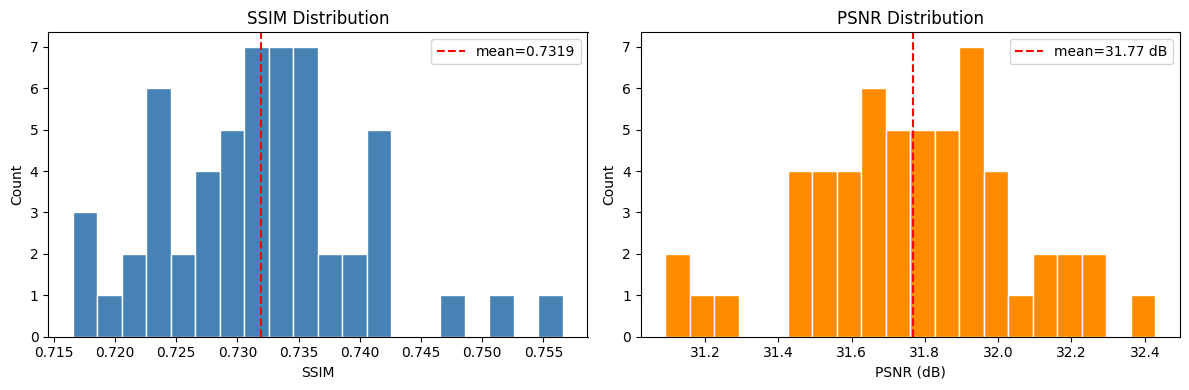

Saved → dataset_results_34/metrics_distribution.png


In [5]:
# ── Distribution plots for SSIM & PSNR ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(ssim_vals, bins=20, color="steelblue", edgecolor="white")
ax1.axvline(np.mean(ssim_vals), color="red", linestyle="--", label=f"mean={np.mean(ssim_vals):.4f}")
ax1.set_title("SSIM Distribution")
ax1.set_xlabel("SSIM")
ax1.set_ylabel("Count")
ax1.legend()

ax2.hist(psnr_vals, bins=20, color="darkorange", edgecolor="white")
ax2.axvline(np.mean(psnr_vals), color="red", linestyle="--", label=f"mean={np.mean(psnr_vals):.2f} dB")
ax2.set_title("PSNR Distribution")
ax2.set_xlabel("PSNR (dB)")
ax2.set_ylabel("Count")
ax2.legend()

plt.tight_layout()
plt.savefig("dataset_results_34/metrics_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → dataset_results_34/metrics_distribution.png")
